In [1]:
import gpflow as gpf
from atkernel import TransferKernel
import tensorflow as tf
import numpy as np
import sys
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple

class SparseCMOGP(gpf.models.GPModel, InternalDataTrainingLossMixin):
    def __init__(self, data, kernel, likelihood, mean_function=None, num_latent_gps=2, inducing_variable=[]):
        super().__init__(kernel, likelihood, mean_function, num_latent_gps)
        self.data = data   
        self.kernel = kernel
        self.likelihood = likelihood
        self.inducing_variable = InducingPoints(inducing_variable)
        self.mean_function = gpf.mean_functions.Zero()
        self.conditioning_indices = [0]
        self.opt_logs = []

        
    def conditional_likelihood(self, *args, **kwargs) -> tf.Tensor:

        # Rebuild: look at all unique indices. 
        # Then, figure out what set to condition on
        # Then, gather all conditioning variables as source, rest as target.
        def get_condition_number(M, name=""):
            s = tf.linalg.svd(M, compute_uv=False)
            tf.print(f"condition number {name}", s[0]/s[-1], s[0], s[-1])
            return 

        Xs, Ys = self.data
        Kall = self.kernel(Xs)
        Xind = self.inducing_variable.Z
        #tf.print(Kall.shape)

        # Determine what is source and what is target (currently use only one target var)
        As = (Ys[:,1]  == 0)
        Bs = (Ys[:,1]  == 1)

        Ax, Ay = tf.reshape(Xs[:,0][As], (-1, 1)), tf.reshape(Ys[:,0][As], (-1, 1))
        Bx, By = tf.reshape(Xs[:,0][Bs], (-1, 1)), tf.reshape(Ys[:,0][Bs], (-1, 1))

        indices_A = tf.reshape(tf.where(As), [-1])
        indices_B = tf.reshape(tf.where(Bs), [-1])

        # Exact matrices
        Kbb = tf.gather(tf.gather(Kall, indices_B, axis=0), indices_B, axis=1)# + tf.linalg.diag(tf.squeeze(self.likelihood.target.variance_at(Bx))) 
        Kaa = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_A, axis=1) 
        Kab = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_B, axis=1)
        Kba = tf.transpose(Kab)

        # Approximate matrices
        Kma = self.kernel(self.inducing_variable.Z, Xs[As])
        Kmb = self.kernel(self.inducing_variable.Z, Xs[Bs])
        Kam = tf.transpose(Kma)
        Kmm = self.kernel(self.inducing_variable.Z) + np.eye(len(Xind), dtype=np.float64) * 1e-6
        L_Kmm = tf.linalg.cholesky(Kmm)
        Lmm_inv_kma = tf.linalg.triangular_solve(L_Kmm, Kma)
        Lmm_inv_kmb = tf.linalg.triangular_solve(L_Kmm, Kmb)

        # Full approximations of the exact matrices
        Qaa = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kma) 
        Qab = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kmb)
        Qba = tf.transpose(Qab)
        
        #LQaa = tf.linalg.cholesky(Qaa + tf.eye(len(Qaa), dtype=tf.float64) * 1e-6) 
        #LQaa_Kab = tf.linalg.triangular_solve(LQaa, Qab)
        
        # Woodbury
        Lambda = tf.linalg.diag(tf.linalg.diag_part(Kaa - Qaa))
        Linv = tf.linalg.inv(Lambda)
        Kminv = tf.linalg.inv(Kmm)
        right_part = tf.linalg.triangular_solve(tf.linalg.cholesky(Kmm + Kma @ Linv @ Kam), Kma @ Linv)
        Qaa_inv = Linv - tf.matmul(right_part, right_part, transpose_a=True)
        Qbb_approx = Qba @ Qaa_inv @ Qab

        #Qbb_approx = tf.matmul(LQaa_Kab, LQaa_Kab, transpose_a=True)
        Qbb = tf.matmul(tf.transpose(Lmm_inv_kmb), Lmm_inv_kmb)

        # FITC-type diagonal

        # Compute conditional mu
        Qaa_L = tf.linalg.cholesky(Qaa + Lambda + tf.linalg.diag(tf.squeeze(self.likelihood.source.variance_at(Ax)))) 
        gamma = tf.linalg.cholesky_solve(Qaa_L, Ay)
        mu_t = tf.matmul(Qba, gamma)
        
        # Compute conditional variance
        Lambda_target =  tf.linalg.diag(tf.linalg.diag_part(Qbb - Qbb_approx))
        C_t = Kbb - Qbb_approx + Lambda_target + tf.linalg.diag(tf.squeeze(self.likelihood.target.variance_at(Bx))) 

        delta = By - mu_t
        L_t = tf.linalg.cholesky(C_t  + tf.eye(tf.shape(C_t)[0], dtype=tf.float64) * 1e-6)
        alpha_t = tf.linalg.cholesky_solve(L_t, delta)
        n_source = tf.cast(tf.shape(Bx)[0], Bx.dtype)
        logdet_t = tf.linalg.logdet(C_t)
        quad = tf.reduce_sum(alpha_t ** 2)
        lml = -0.5 * (logdet_t + quad + n_source * tf.cast(tf.math.log(2*np.pi), Ax.dtype))
        #tf.print(quad, logdet_t)
        return tf.squeeze(lml)

    def maximum_log_likelihood_objective(self):
        return self.conditional_likelihood()


    def predict_f(
        self, Xnew, full_cov: bool = False, full_output_cov: bool = False):
        r"""
        Allegedly, the GP prediction stays the same, so instead of creating an inference shaped footgun, use GPFlow methods.
        This method computes predictions at X \in R^{N \x D} input points

        .. math::
            p(F* | Y)

        where F* are points on the GP at new data points, Y are noisy observations at training data
        points.
        """

        Xs, Ys = self.data
        Xind = self.inducing_variable.Z
        Kall = self.kernel(Xs)
        err = (Ys - self.mean_function(Xs))[:,0][:,None]
      
        As = (Ys[:,1] == 0)
        Bs = (Ys[:,1] == 1)

        knn = self.kernel(Xnew, full_cov=full_cov) + tf.squeeze(self.likelihood.target.variance_at(Xnew))

        Ax, Ay = tf.reshape(Xs[:,0][As], (-1, 1)), tf.reshape(Ys[:,0][As], (-1, 1))
        Bx, By = tf.reshape(Xs[:,0][Bs], (-1, 1)), tf.reshape(Ys[:,0][Bs], (-1, 1))

        indices_A = tf.reshape(tf.where(As), [-1])
        indices_B = tf.reshape(tf.where(Bs), [-1])
       
        # Compute exact kernel parts
        Kbb = tf.gather(tf.gather(Kall, indices_B, axis=0), indices_B, axis=1) 
        Kaa = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_A, axis=1) 
        Kab = tf.gather(tf.gather(Kall, indices_A, axis=0), indices_B, axis=1)
        Kba = tf.transpose(Kab)

        # Compute inducing points x rest data 
        Kma = self.kernel(self.inducing_variable.Z, Xs[As])
        Kmb = self.kernel(self.inducing_variable.Z, Xs[Bs])
        Kam = tf.transpose(Kma)
        Kmm = self.kernel(self.inducing_variable.Z) + np.eye(len(Xind.numpy()), dtype=np.float64) * 1e-6
        L_Kmm = tf.linalg.cholesky(Kmm)
        Lmm_inv_kma = tf.linalg.triangular_solve(L_Kmm, Kma)
        Lmm_inv_kmb = tf.linalg.triangular_solve(L_Kmm, Kmb)

        # Use above to compute approximations and diagonal
        Qaa = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kma)
        Qab = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kmb)
        Qba = tf.transpose(Qab)
        Qbb = tf.matmul(tf.transpose(Lmm_inv_kmb), Lmm_inv_kmb)
        Lambda = tf.linalg.diag(tf.linalg.diag_part(Kaa - Qaa))
        Lambda_t = tf.linalg.diag(tf.linalg.diag_part(Kbb - Qbb))

        #tf.print(self.inducing_variable.Z)
        K_fitc = tf.concat((tf.concat((Qaa + Lambda, Qab), 1), tf.concat((Qba, Kbb), 1)), 0)
        L_Kfitc = tf.linalg.cholesky(K_fitc + tf.eye(len(Xs), dtype=tf.float64) * 1e-5)

        #tf.print(kmm_plus_s.shape)
        # Construct Kmn
        Knm = self.kernel(Xs, self.inducing_variable.Z) @ tf.linalg.inv(Kmm) @ self.kernel(self.inducing_variable.Z, Xnew)
        LfitcKnm = tf.linalg.triangular_solve(L_Kfitc, Knm)
        Kfitcy = tf.linalg.cholesky_solve(L_Kfitc, err)
      
        cond = tf.transpose(LfitcKnm) @ LfitcKnm  
        f_mean_zero = tf.transpose(Knm) @ Kfitcy
        f_var = tf.expand_dims(tf.linalg.diag_part(knn - cond), 1)
        fvar = knn - tf.reduce_sum(tf.square(LfitcKnm), -2)  # [..., N]
        fvar = tf.expand_dims(fvar, -2)
        #tf.print("fm0", f_mean_zero.shape)
        f_mean = f_mean_zero + self.mean_function(Xnew[:,0][:,None])
        return f_mean, f_var

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()


2026-04-14 16:57:38.401727: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 16:57:38.407526: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-14 16:57:38.466402: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-14 16:57:38.468191: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-14 16:57:39.512404: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[  0   3   6   9  12  15  18  21  24  27  30  33  36  39  42  45  48  51
  54  57  60  63  66  69  72  75  78  81  84  87  90  93  96  99 102 105
 108 111 114 117 120 123 126 129 132 135 138 141 144 147 150 153 156 159
 162 165 168 171 174 177 180 183 186 189 192 195 198 201 204 207 210 213
 216 219 222 225 228 231 234 237 240 243 246 249 252 255 258 261 264 267
 270 273 276 279 282 285 288 291 294 297]


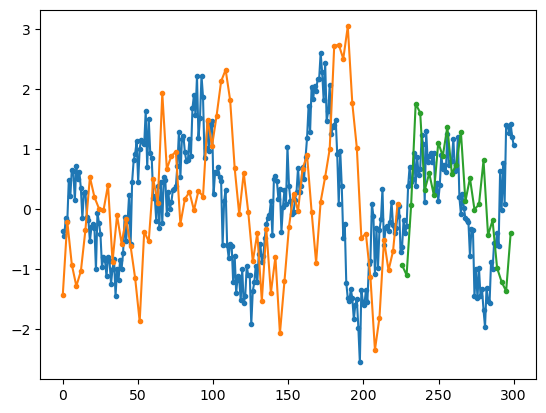

In [2]:
k = gpf.kernels.RBF(lengthscales=10, variance=1) #+ gpf.kernels.Linear(0.001)
Xall = np.linspace(0, 300, 300)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 300, 1)
ind_2 = np.array([i for i in ind_1 if i % 3 == 0])
ind_1 = ind_1[0:300]
ind_2 = ind_2 
print(ind_2)
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2 - X2[0]
y2 = np.roll(y2, 5)
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = np.roll(1 * ytest.reshape(-1, 1) + np.random.normal(0, 0.5, len(ytest)).reshape(-1, 1), 5)

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.3, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.5, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value       │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0         │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0         │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────┤
│ SparseCMOGP

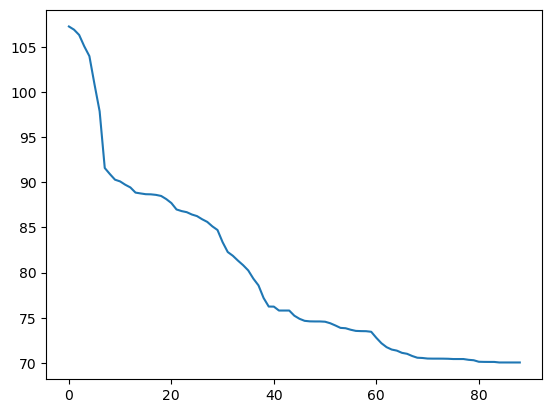

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 3.98848                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 8.20297                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─

In [3]:


output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
probs = np.array([len(ind_1), len(ind_2)])/(len(ind_2) + len(ind_1))
ivs = np.linspace(0, len(Xall), 100).reshape(-1, 1)
iv_ind = np.random.permutation(np.concatenate( (np.zeros((int(len(ivs)/2), 1)), np.ones((int(len(ivs)/2), 1)) ), axis=0))
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

In [4]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)
 

### Ours

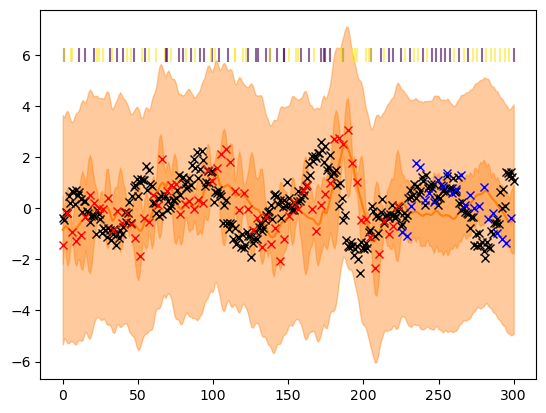

1.0376680267718046

In [5]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*6, marker="|", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

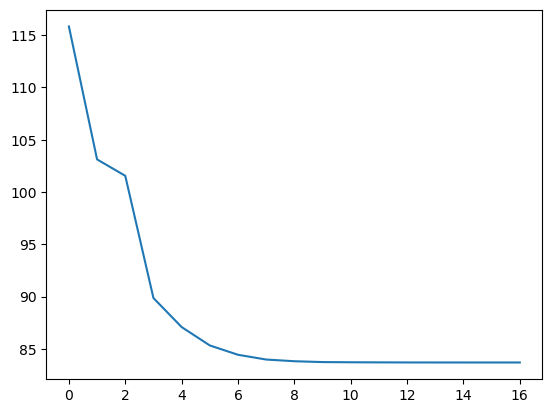

In [6]:
kern = gpf.kernels.Matern32()
m = gpf.models.GPR((X2, y2), kernel=kern)
gpf.utilities.print_summary(m)
optimize(m)

### Regular GP

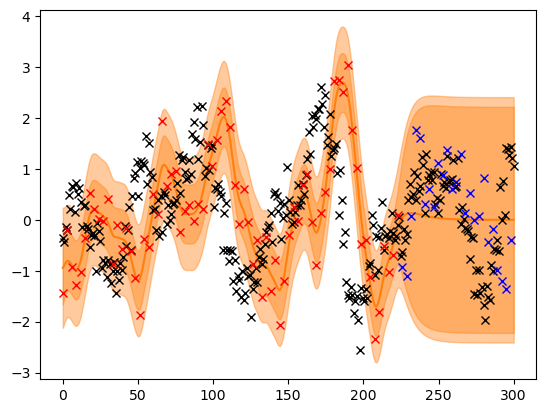

0.7851579580616544

In [7]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = Xall
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

regular_gp_mse = mean_squared_error(ytest, fmean_tst)
regular_gp_mse

### Comparison with exact MOGP

In [8]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.VGP((X, y), kernel=kern, likelihood=lik)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 236.61922212305774
        x: [-2.928e-01  7.963e-01 ... -2.259e+00 -1.359e+00]
      nit: 282
      jac: [-2.278e-04 -1.852e-04 ...  1.118e-03  5.721e-05]
     nfev: 312
     njev: 312
 hess_inv: <70883x70883 LbfgsInvHessProduct with dtype=float64>

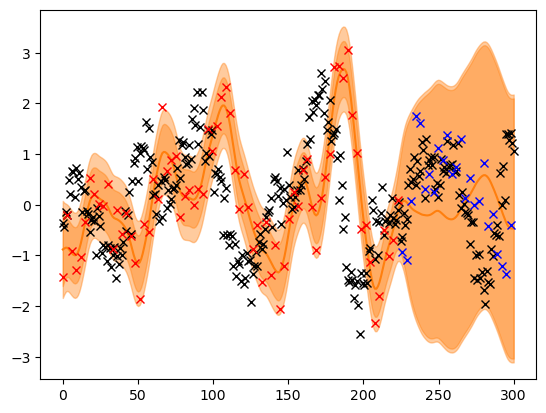

0.9747758696037951

In [9]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)

plt.show()

exact_mogp_mse = mean_squared_error(ytest, fmean_tst)
exact_mogp_mse


In [10]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)

probs = np.array([len(ind_1), len(ind_2)])/(len(ind_2) + len(ind_1))
ivs = np.linspace(0, len(Xall), 100).reshape(-1, 1)
ivs = np.hstack((ivs, np.random.choice([0, 1], p=[0.5, 0.5], size=len(ivs)).reshape(-1, 1)))

X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-04-14 16:58:21.953338: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-04-14 16:58:21.993838: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 272.1890112253645
        x: [ 2.606e-01  1.122e+00 ... -2.247e+00  1.069e+00]
      nit: 1296
      jac: [ 8.457e-04 -6.203e-04 ...  3.018e-04  4.644e-05]
     nfev: 1348
     njev: 1348
 hess_inv: <5358x5358 LbfgsInvHessProduct with dtype=float64>

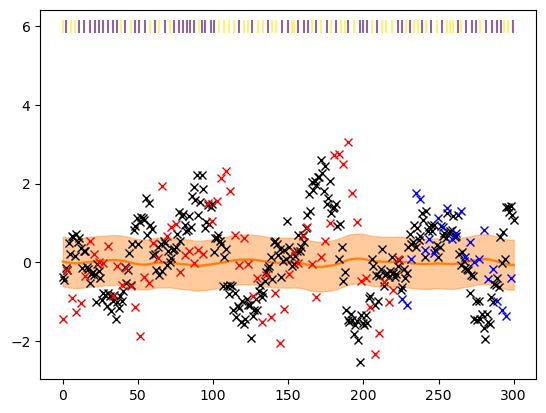

In [11]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs)[:,0]*6, marker="|", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

approximate_mogp_mse = mean_squared_error(ytest, fmean_tst)

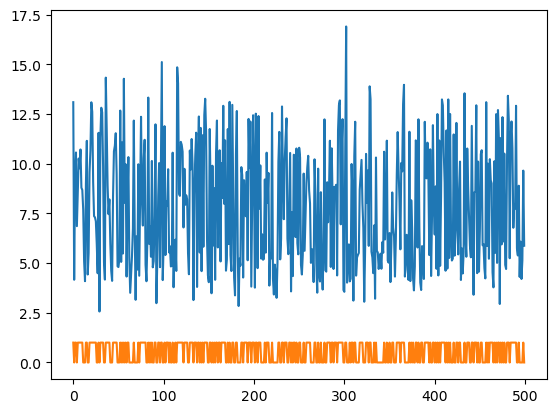

In [13]:
import numpy as np


B = np.random.binomial(1, 0.5, 500)
A = np.where(B == 0, 
             np.random.normal(5, 1, 500),     
             np.random.normal(10, 2, 500)) 

plt.plot(A)
plt.plot(B)   

In [12]:
print(ours_mse)
print(regular_gp_mse)
print(exact_mogp_mse)
print(approximate_mogp_mse)

1.0376680267718046
0.7851579580616544
0.9747758696037951
0.8381811726218531
